In [1]:
from typing import Callable, List, Optional, Tuple, Union

import scanpy as sc
import scvelo as scv
import anndata as ad
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.cm as cm
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.patches import FancyArrowPatch

import pandas as pd
import numpy as np
import pickle
from sklearn import preprocessing
import json
import torch
from torch import nn
from torch.autograd.functional import jacobian
import os
import shutil
from torchdiffeq import odeint
from sklearn.decomposition import PCA
from scipy.io import loadmat
from scipy.interpolate import interp1d
from scipy.optimize import OptimizeResult, minimize
from scipy.stats import pearsonr,spearmanr

import dynamo as dyn
dyn.dynamo_logger.main_silence()
sc.settings.set_figure_params(dpi=80, dpi_save=300, fontsize=14)
plt.rcParams['axes.grid'] = False
plt.rcParams['svg.fonttype']='none'
plt.rcParams['font.family'] = 'Arial'

import warnings
warnings.filterwarnings('ignore')

In [2]:
## 读取数据
with open('data(d=0.01).pickle', 'rb') as f:
    data = pickle.load(f)
data.shape

with open('data_with_phase.pickle', 'rb') as f:
    data_with_phase = pickle.load(f)
data_with_phase.shape

(8000, 45)

In [3]:
np_data = data_with_phase[:, :-1]

In [4]:
## 归一化（标准化）细胞数据
# np_data = (np_data - np_data.mean(0))/np_data.std(0)
np_data = (np_data - np_data.min(0))/(np_data.max(0) - np_data.min(0))

np_data.shape

(8000, 44)

In [5]:
## 转换为伪时间
percentiles = np.percentile(data_with_phase[:,-1], np.linspace(0, 100, 1000))
indices = np.digitize(data_with_phase[:,-1], percentiles)
pseudotime = indices * 0.001

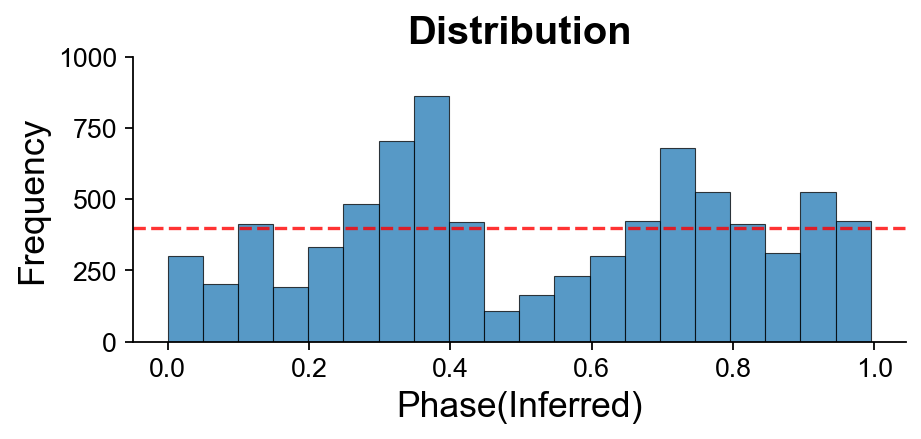

In [6]:
plt.figure(figsize=(6, 3))
plt.hist(data_with_phase[:, -1], bins=20, edgecolor='black', alpha=0.75)
plt.axhline(y=400, color='r', linestyle='--', linewidth=1.5, alpha=0.8)

plt.xlabel('Phase(Inferred)', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.ylim(0, 1000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribution', fontsize=18, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./figures/theta_distribution.svg', bbox_inches='tight', transparent=True)
plt.show()

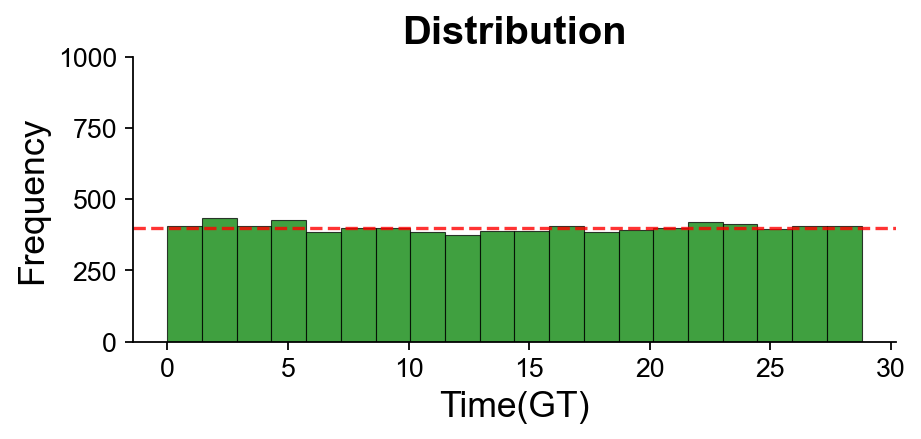

In [7]:
plt.figure(figsize=(6, 3))
plt.hist(data[:,-1], bins=20, edgecolor='black', color='green', alpha=0.75)
plt.axhline(y=400, color='r', linestyle='--', linewidth=1.5, alpha=0.8)

plt.xlabel('Time(GT)', fontsize=16)
plt.ylabel('Frequency', fontsize=16)
plt.ylim(0, 1000)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.title('Distribution', fontsize=18, fontweight='bold')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('./figures/time_distribution.svg', bbox_inches='tight', transparent=True)
plt.show()

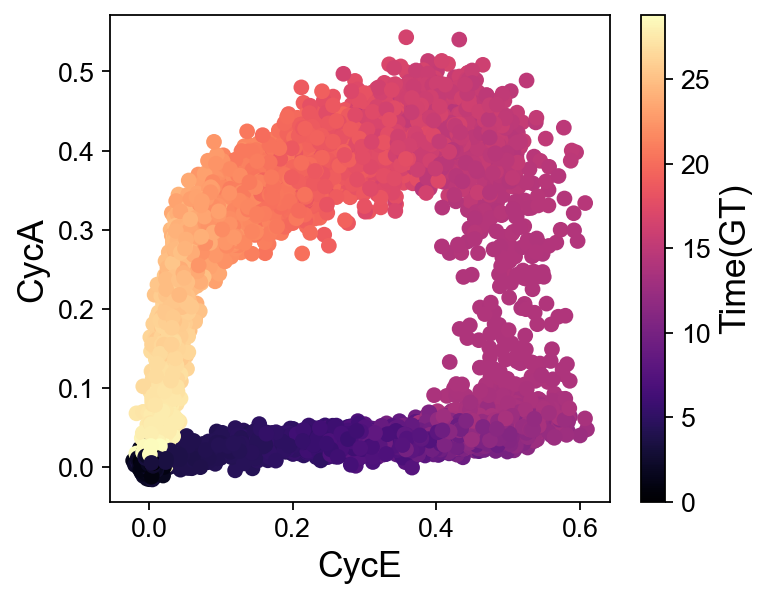

In [8]:
fig, ax = plt.subplots(figsize=(5, 4))

sc = ax.scatter(data[:, 14], data[:, 21], c=data[:, -1], 
                cmap=cm.magma, s=50, alpha=1, edgecolors='none', rasterized=True)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Time(GT)', fontsize=16)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel(f'CycE', fontsize=16)
ax.set_ylabel(f'CycA', fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=12)

plt.savefig('./figures/raw_data.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

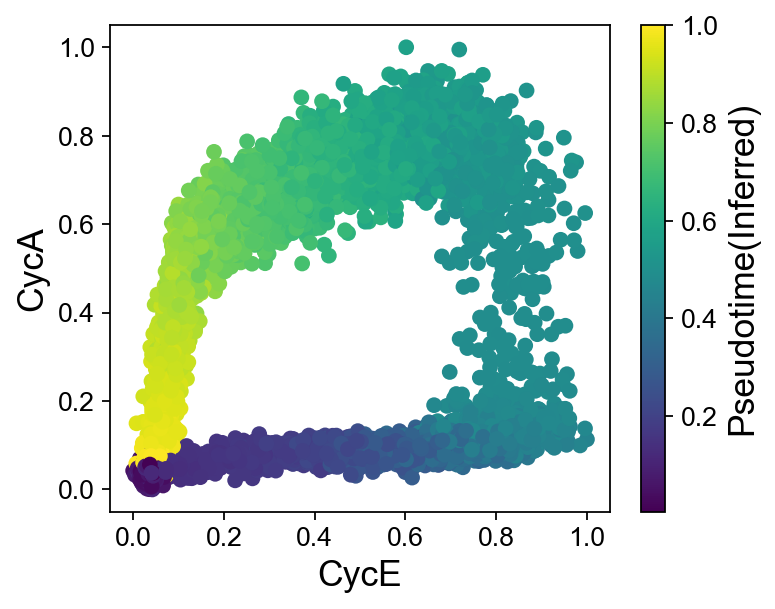

In [9]:
fig, ax = plt.subplots(figsize=(5, 4))

sc = ax.scatter(np_data[:, 14], np_data[:, 21], c=pseudotime, 
                cmap=cm.viridis, s=50, alpha=1, edgecolors='none', rasterized=True)

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Pseudotime(Inferred)', fontsize=16)
cbar.ax.tick_params(labelsize=12)

ax.set_xlabel(f'CycE', fontsize=16)
ax.set_ylabel(f'CycA', fontsize=16)

ax.tick_params(axis='both', which='major', labelsize=12)

plt.savefig('./figures/theta_data.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [10]:
corr_coef, p_value = pearsonr(data_with_phase[:,-1],data[:,-1])
print("Pearson correlation coefficient:", corr_coef)
print("P-value:", p_value)

Pearson correlation coefficient: 0.9712902187644399
P-value: 0.0


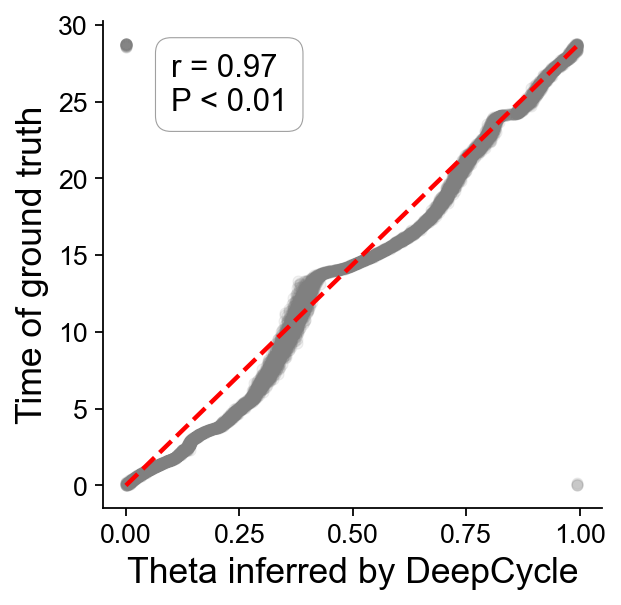

In [11]:
x = np.linspace(0, 1, 100)
y = 28.80 * x

plt.figure(figsize=(4, 4))
plt.scatter(data_with_phase[:,-1],data[:,-1], c='gray', s=25, alpha=0.1, rasterized=True)
plt.plot(x, y, '--', color='red', linewidth=2, )

equation_text = f'r = {corr_coef:.2f}\nP < 0.01'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='gray')
plt.text(0.1 * data_with_phase[:,-1].max(), 0.85 * data[:,-1].max(), equation_text, fontsize=14, bbox=props, family='Arial')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Theta inferred by DeepCycle', fontsize=16)
plt.ylabel('Time of ground truth', fontsize=16)

plt.savefig('./figures/theta_compare.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [12]:
corr_coef, p_value = pearsonr(pseudotime,data[:,-1])
print("Pearson correlation coefficient:", corr_coef)
print("P-value:", p_value)

Pearson correlation coefficient: 0.9780281324536
P-value: 0.0


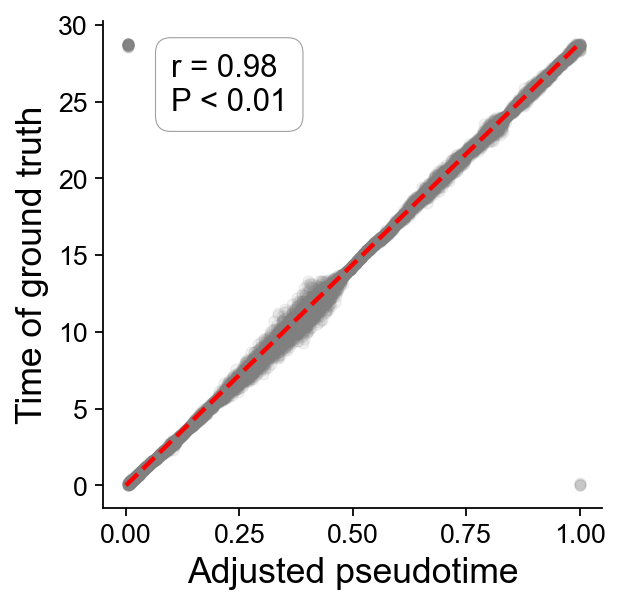

In [13]:
x = np.linspace(0, 1, 100)
y = 28.80 * x

plt.figure(figsize=(4, 4))
plt.scatter(pseudotime,data[:,-1], c='gray', s=25, alpha=0.1, rasterized=True)
plt.plot(x, y, '--', color='red', linewidth=2, )

equation_text = f'r = {corr_coef:.2f}\nP < 0.01'
props = dict(boxstyle='round,pad=0.5', facecolor='white', alpha=0.75, edgecolor='gray')
plt.text(0.1 * data_with_phase[:,-1].max(), 0.85 * data[:,-1].max(), equation_text, fontsize=14, bbox=props, family='Arial')

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.xlabel('Adjusted pseudotime', fontsize=16)
plt.ylabel('Time of ground truth', fontsize=16)

plt.savefig('./figures/pseudotime_compare.svg', bbox_inches='tight', transparent=True, dpi=300)
plt.show()

In [14]:
## 按相位角划分数据
n_bins = 50
bin_labels = np.arange(n_bins)
bin_edges = np.percentile(data_with_phase[:, -1], np.linspace(0, 100, n_bins+1))

In [15]:
bin_edges

array([0.        , 0.02132667, 0.05433333, 0.09562667, 0.12133333,
       0.139     , 0.15825333, 0.20362   , 0.22666667, 0.24927333,
       0.273     , 0.28626   , 0.29858667, 0.31191333, 0.32357333,
       0.33466667, 0.344     , 0.354     , 0.36333333, 0.372     ,
       0.38      , 0.39      , 0.39985333, 0.40966667, 0.42817333,
       0.495     , 0.54333333, 0.58115333, 0.60933333, 0.63733333,
       0.6618    , 0.68146   , 0.69578667, 0.70866667, 0.72033333,
       0.73133333, 0.74233333, 0.75533333, 0.773     , 0.787     ,
       0.80133333, 0.80966667, 0.82605333, 0.87633333, 0.89404   ,
       0.90766667, 0.92166667, 0.93770667, 0.96001333, 0.98066667,
       0.995     ])

In [16]:
bins = pd.cut(data_with_phase[:, -1], bins=bin_edges, labels=bin_labels, include_lowest=True)
bins.value_counts()

0     160
1     163
2     157
3     162
4     159
5     159
6     160
7     162
8     158
9     161
10    159
11    160
12    160
13    160
14    178
15    148
16    155
17    171
18    152
19    162
20    157
21    157
22    162
23    158
24    161
25    160
26    159
27    161
28    164
29    155
30    160
31    160
32    163
33    158
34    160
35    164
36    157
37    159
38    162
39    159
40    162
41    156
42    161
43    159
44    162
45    159
46    159
47    160
48    165
49    155
Name: count, dtype: int64

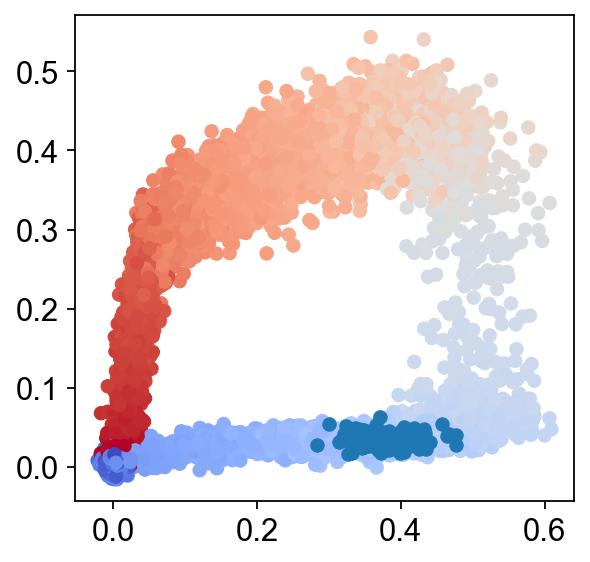

In [17]:
bdata = data_with_phase[bins == 15]
plt.scatter(data_with_phase[:, 14], data_with_phase[:, 21], c=data_with_phase[:,-1],cmap=cm.coolwarm)
plt.scatter(bdata[:, 14], bdata[:, 21])

In [18]:
## PCA降维
pca = PCA(n_components=2)
pca.fit(np_data)
V = pca.components_.T
ratio = pca.explained_variance_ratio_
np_data_pca = (np_data - np.mean(np_data, axis=0)) @ V

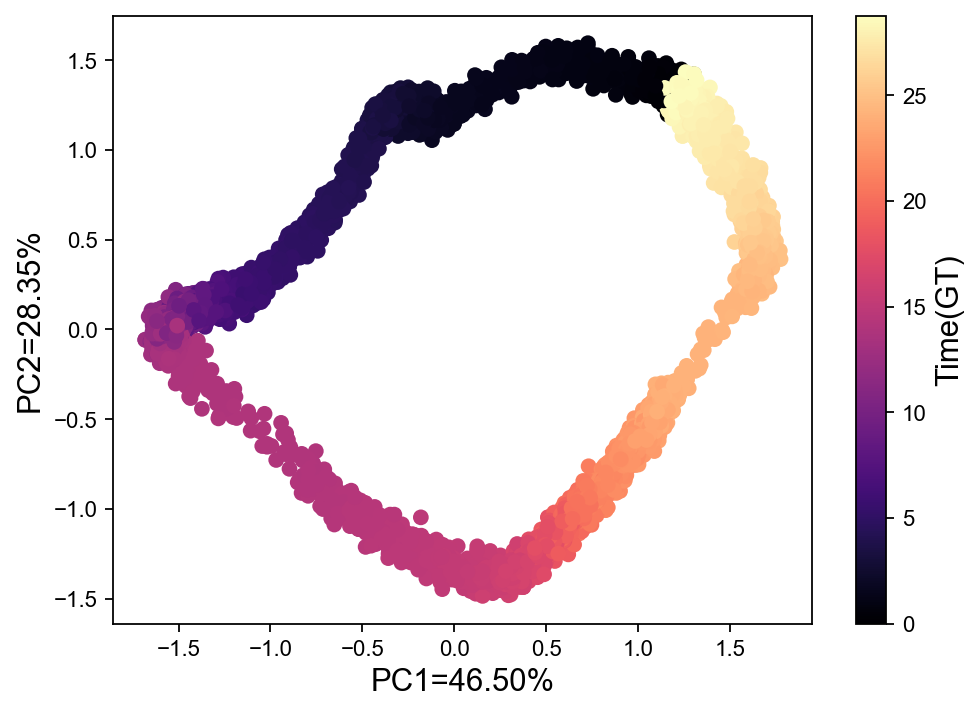

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))

sc = ax.scatter(np_data_pca[:, 0], np_data_pca[:, 1], c=data[:, -1], 
                cmap=cm.magma, s=50, alpha=1, edgecolors='none')

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Time(GT)', fontsize=14)
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel(f'PC1={ratio[0] * 100:.2f}%', fontsize=14)
ax.set_ylabel(f'PC2={ratio[1] * 100:.2f}%', fontsize=14)

ax.tick_params(axis='both', which='major', labelsize=10)

In [20]:
cwd = os.getcwd()
print("[Current working directory]:",cwd)
scatter_dir = cwd+'/scatters/'

try:
    if os.path.exists(scatter_dir):
        shutil.rmtree(scatter_dir, ignore_errors=True)
        os.mkdir(scatter_dir)
    else:
        os.mkdir(scatter_dir)
except:
    print("[ERROR]: Creation of the directory %s failed" % scatter_dir)
    raise

[Current working directory]: D:\ROG\desktop\振荡动力学推断结果整理\code\44dim_cell_cycle


In [21]:
for index in range(44):
    plt.scatter(data_with_phase[:, -1], np_data[:, index], c=data_with_phase[:, -1], cmap='viridis', marker='.')
    plt.colorbar(label='Time')
    plt.xlabel('Time')
    plt.ylabel('gene' + str(index))
    plt.title('gene' + str(index))
    plt.savefig(scatter_dir+str(index)+'.png', dpi=300)
    plt.clf()

<Figure size 320x320 with 0 Axes>

In [22]:
## 采样数据
k = 40 # 周期个数
NN = k * n_bins
data = np.zeros([np_data.shape[1], 50, NN])
for j in range(50):
    # 每个bin采样
    sample_indices = []
    for _ in range(k):
        for i in range(n_bins):
            bin_indices = np.where(bins == i)[0]
            if len(bin_indices) > 0:
                random_index = np.random.choice(bin_indices)
                sample_indices.append(random_index)
    data[:, j, :] = np_data[sample_indices,:].T

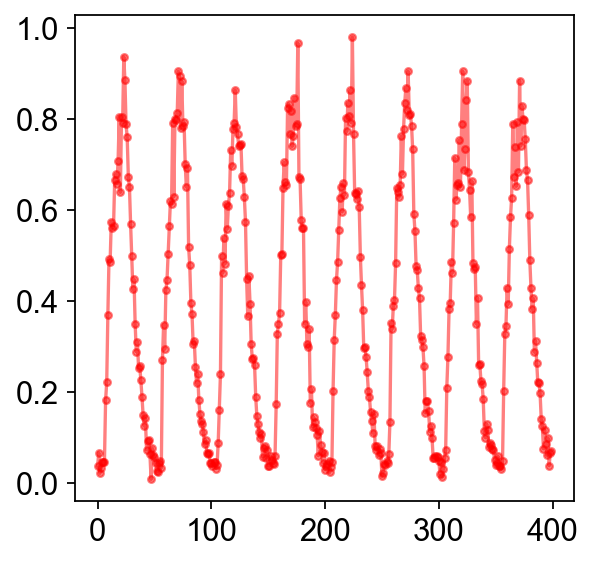

In [23]:
n = 14
fig, ax = plt.subplots()
ax.plot(range(400),data[n, 0, :400],'.-',alpha=0.5,color='red')

In [24]:
youtcome=np.zeros([97550, np_data.shape[1], 50, 1], dtype=np.float32)
for i in range(97550):
    j = i//1951
    k = i % 1951
    youtcome[i, :, :, :] = data[:, j, k:k+50].reshape(np_data.shape[1], 50, 1)

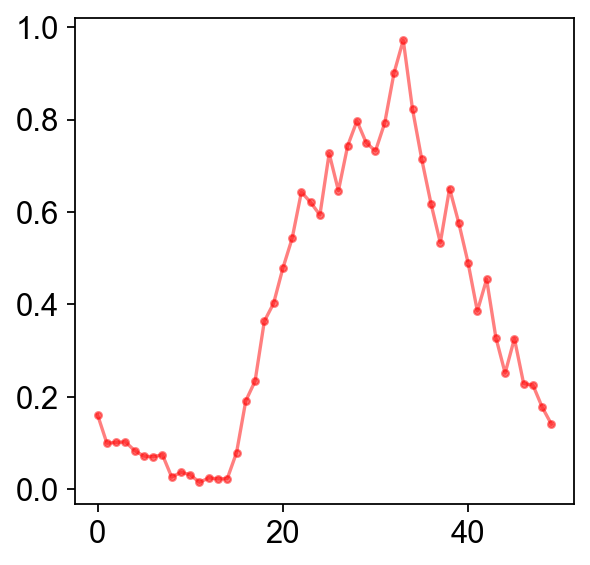

In [25]:
n = 14
fig, ax = plt.subplots()
ax.plot(range(50),youtcome[97540, n, :, :],'.-',alpha=0.5,color='red')

In [26]:
index = [o for o in range(youtcome.shape[0])]
np.random.shuffle(index)
ynew = youtcome[index, :, :, :]
train_data = ynew[: youtcome.shape[0] // 10 * 8, :, :, :]
val_data = ynew[youtcome.shape[0] // 10 * 8:youtcome.shape[0] // 10 * 9, :, :, :]
test_data = ynew[youtcome.shape[0] // 10 * 9:, :, :, :]

train_data = torch.tensor(train_data)
val_data = torch.tensor(val_data)
test_data = torch.tensor(test_data)

print('\n Train data size:', train_data.shape)
print('\n Val data size:' , val_data.shape)
print('\n Test data size:' , test_data.shape)
print('\n----------   Finsh generating time series data ----------')


 Train data size: torch.Size([78040, 44, 50, 1])

 Val data size: torch.Size([9755, 44, 50, 1])

 Test data size: torch.Size([9755, 44, 50, 1])

----------   Finsh generating time series data ----------


In [27]:
results = [train_data, val_data, test_data]

In [28]:
# with open('data.pickle', 'wb') as f:
#     pickle.dump(results, f)